# Tree-Based Models for Machine Learning

This notebook covers decision trees, random forests, and gradient boosting—fundamental algorithms for both classification and regression tasks.

📺 **Video Lecture:** [https://youtu.be/v9OmF4GFaqw](https://youtu.be/v9OmF4GFaqw)

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style('whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Decision Tree Basics

A decision tree recursively splits data based on feature values to minimize impurity (Gini or entropy).

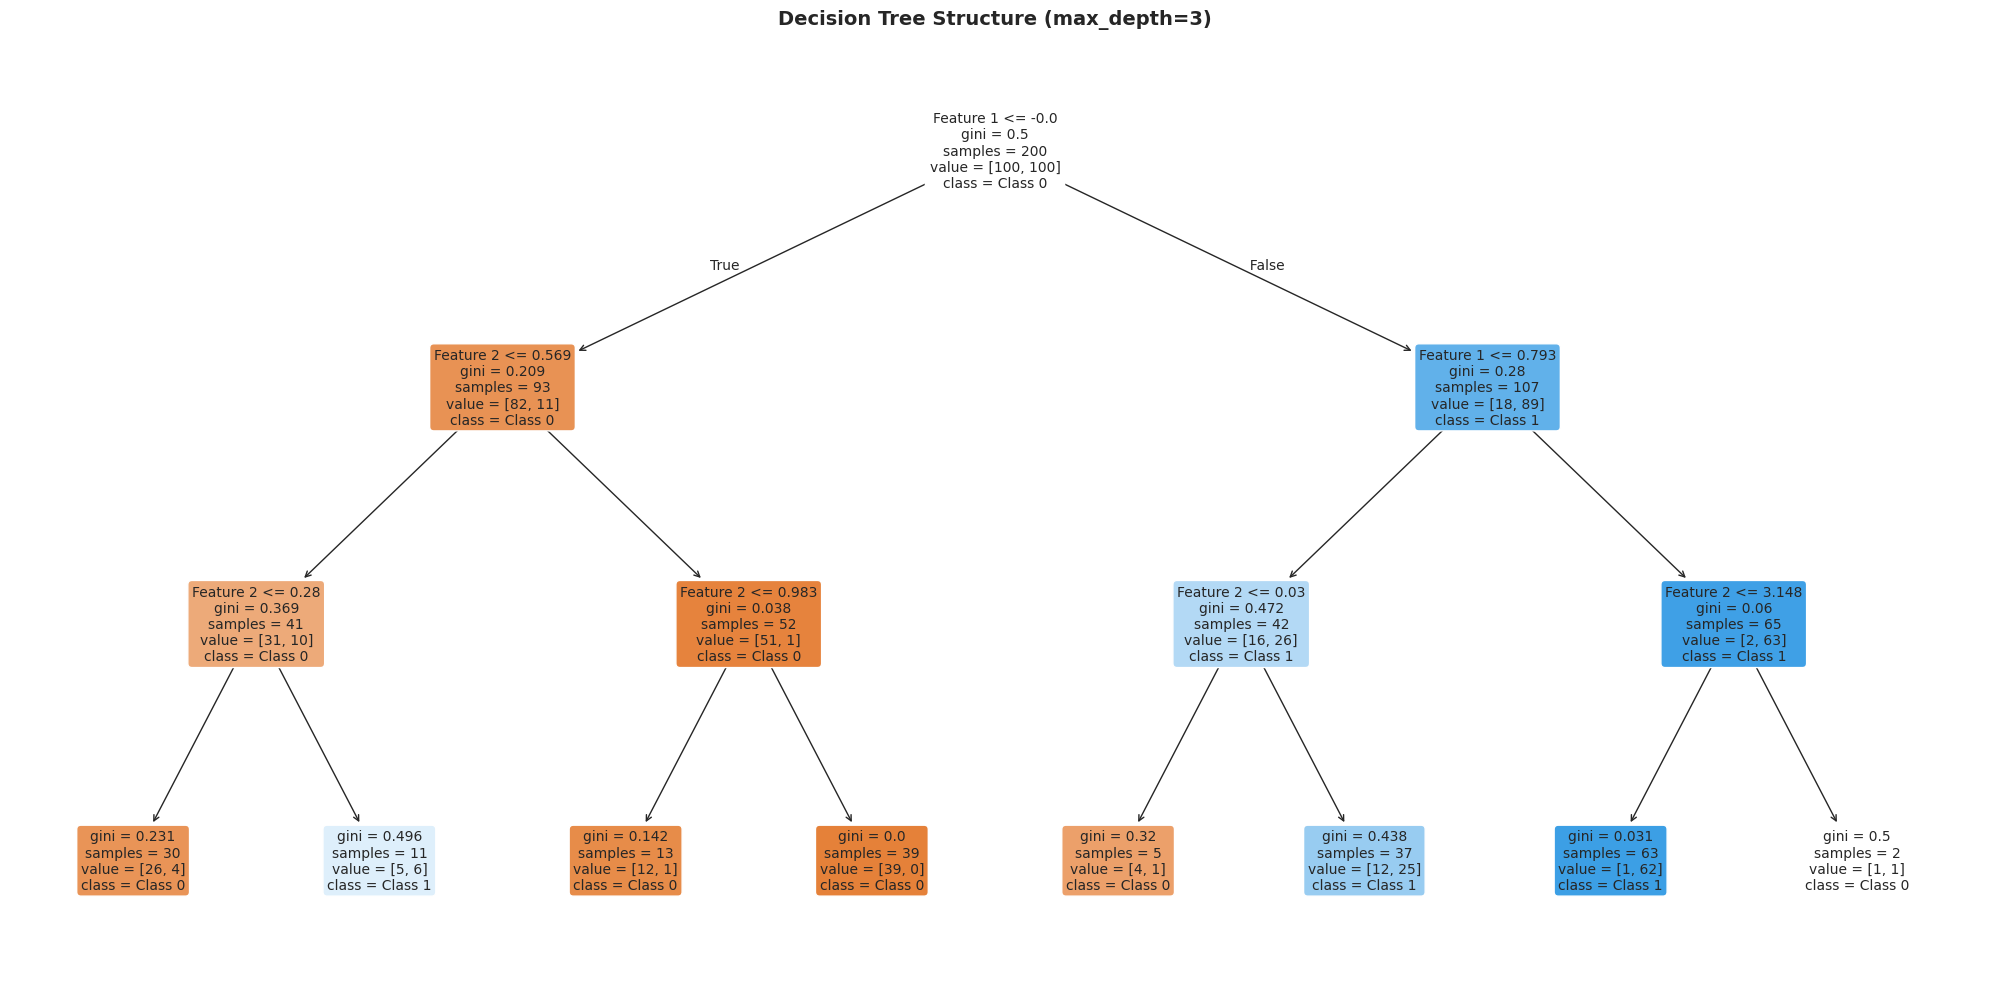

Tree Accuracy: 0.8750
Tree Depth: 3
Number of Leaves: 8


In [3]:
# Create synthetic classification dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, 
                            n_redundant=0, random_state=42, n_clusters_per_class=1)

# Train a simple decision tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, y)

# Plot the tree structure
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Tree Accuracy: {dt.score(X, y):.4f}')
print(f'Tree Depth: {dt.get_depth()}')
print(f'Number of Leaves: {dt.get_n_leaves()}')

## 2. Gini vs Entropy Impurity Measures

Both Gini and entropy measure how mixed a node is. Gini is faster to compute.

Gini Criterion - Accuracy: 0.9350
Entropy Criterion - Accuracy: 0.9000
Difference: 0.0350


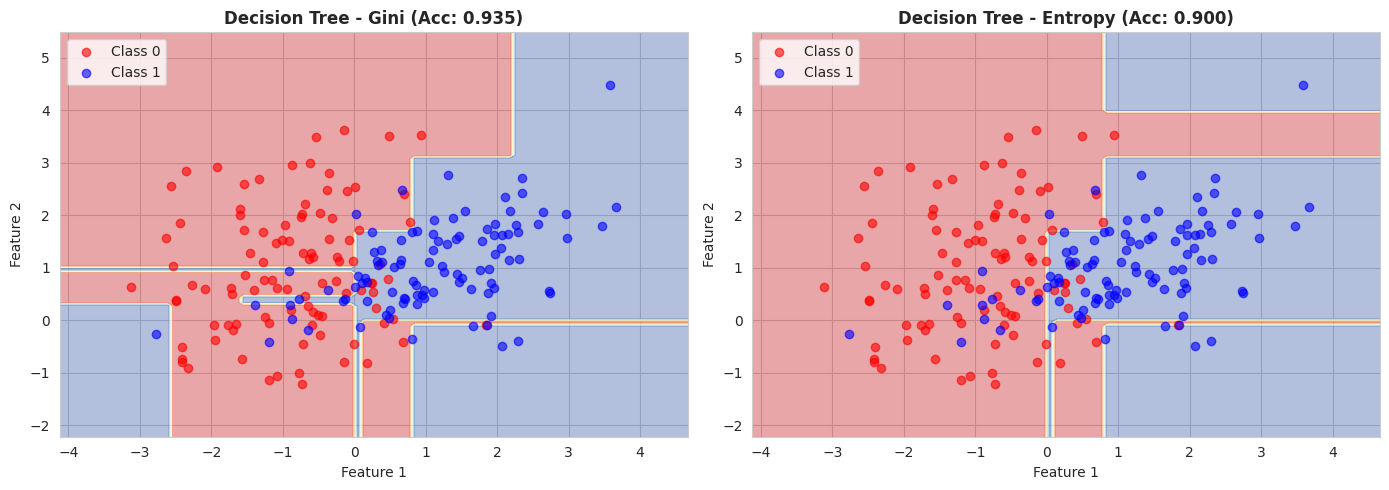

In [4]:
# Train trees with different splitting criteria
dt_gini = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)

dt_gini.fit(X, y)
dt_entropy.fit(X, y)

# Compare accuracy
acc_gini = dt_gini.score(X, y)
acc_entropy = dt_entropy.score(X, y)

print(f'Gini Criterion - Accuracy: {acc_gini:.4f}')
print(f'Entropy Criterion - Accuracy: {acc_entropy:.4f}')
print(f'Difference: {abs(acc_gini - acc_entropy):.4f}')

# Visualize decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (dt, name) in enumerate([(dt_gini, 'Gini'), (dt_entropy, 'Entropy')]):
    # Create mesh
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                          np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))
    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    axes[idx].scatter(X[y==0, 0], X[y==0, 1], c='red', label='Class 0', alpha=0.6)
    axes[idx].scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class 1', alpha=0.6)
    axes[idx].set_title(f'Decision Tree - {name} (Acc: {dt.score(X, y):.3f})', fontweight='bold')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 3. Random Forest: Bootstrap Aggregation

Random Forest trains multiple trees on bootstrap samples and averages predictions.

Random Forest Accuracy: 0.9150
Feature Importances:
  Feature 1: 0.7679
  Feature 2: 0.2321


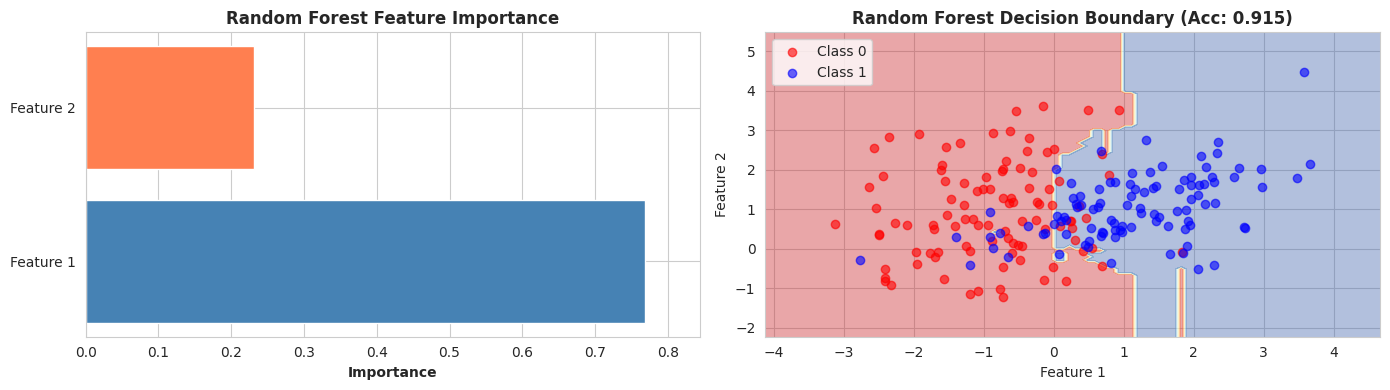

In [5]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

# Get feature importances
feature_importance = rf.feature_importances_

print(f'Random Forest Accuracy: {rf.score(X, y):.4f}')
print(f'Feature Importances:')
print(f'  Feature 1: {feature_importance[0]:.4f}')
print(f'  Feature 2: {feature_importance[1]:.4f}')

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Feature importance bar plot
axes[0].barh(['Feature 1', 'Feature 2'], feature_importance, color=['steelblue', 'coral'])
axes[0].set_xlabel('Importance', fontweight='bold')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlim([0, max(feature_importance) * 1.1])

# Decision boundary for Random Forest
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                      np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))
Z = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
axes[1].scatter(X[y==0, 0], X[y==0, 1], c='red', label='Class 0', alpha=0.6)
axes[1].scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class 1', alpha=0.6)
axes[1].set_title(f'Random Forest Decision Boundary (Acc: {rf.score(X, y):.3f})', fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Out-of-Bag (OOB) Error Demonstration

OOB samples (not in bootstrap) can estimate generalization error without separate validation set.

In [6]:
# Train Random Forest with OOB error tracking
rf_oob = RandomForestClassifier(n_estimators=100, max_depth=5, oob_score=True, random_state=42)
rf_oob.fit(X, y)

train_acc = rf_oob.score(X, y)
oob_score = rf_oob.oob_score_

print(f'Training Accuracy: {train_acc:.4f}')
print(f'OOB Score (Generalization Estimate): {oob_score:.4f}')
print(f'Difference (potential overfitting): {train_acc - oob_score:.4f}')

# Compare with single tree
dt_single = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_single.fit(X, y)

results = pd.DataFrame({
    'Model': ['Single Tree', 'Random Forest (OOB estimate)'],
    'Accuracy': [dt_single.score(X, y), train_acc],
    'Estimated Generalization': [dt_single.score(X, y), oob_score]
})

print('\nModel Comparison:')
print(results.to_string(index=False))

Training Accuracy: 0.9150
OOB Score (Generalization Estimate): 0.8150
Difference (potential overfitting): 0.1000

Model Comparison:
                       Model  Accuracy  Estimated Generalization
                 Single Tree     0.935                     0.935
Random Forest (OOB estimate)     0.915                     0.815


## 5. Hyperparameter Tuning Effect: max_depth

Changing max_depth affects overfitting vs underfitting trade-off.

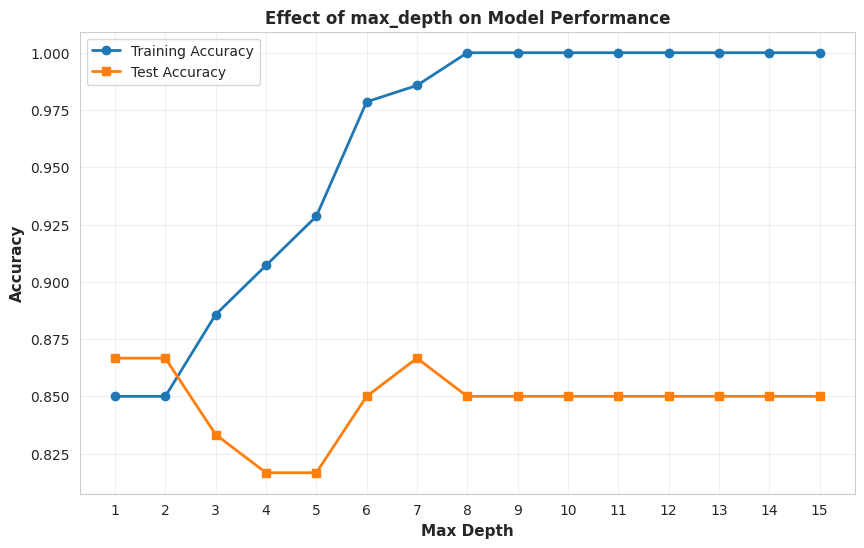

Optimal max_depth: 1
Test Accuracy at optimal depth: 0.8667


In [7]:
# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Test different max_depth values
depths = range(1, 16)
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, 'o-', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(depths, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=6)
plt.xlabel('Max Depth', fontweight='bold', fontsize=11)
plt.ylabel('Accuracy', fontweight='bold', fontsize=11)
plt.title('Effect of max_depth on Model Performance', fontweight='bold', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()

# Find optimal depth
optimal_depth = depths[np.argmax(test_accs)]
print(f'Optimal max_depth: {optimal_depth}')
print(f'Test Accuracy at optimal depth: {max(test_accs):.4f}')

## 6. n_estimators Effect in Random Forest

Adding more trees reduces variance but with diminishing returns.

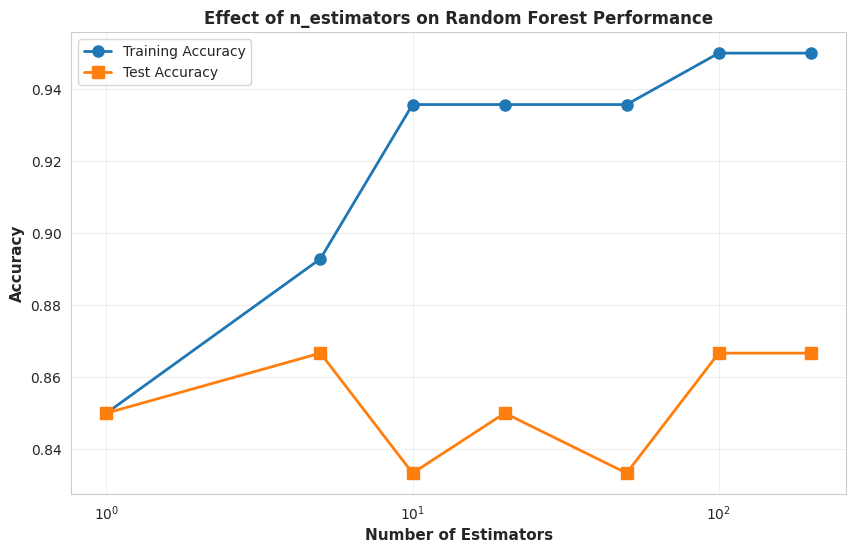

n_estimators effect on test accuracy:
    1 estimators: 0.8500
    5 estimators: 0.8667
   10 estimators: 0.8333
   20 estimators: 0.8500
   50 estimators: 0.8333
  100 estimators: 0.8667
  200 estimators: 0.8667


In [8]:
# Test different numbers of estimators
n_estimators_range = [1, 5, 10, 20, 50, 100, 200]
train_scores = []
test_scores = []

for n_est in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(n_estimators_range, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators', fontweight='bold', fontsize=11)
plt.ylabel('Accuracy', fontweight='bold', fontsize=11)
plt.title('Effect of n_estimators on Random Forest Performance', fontweight='bold', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

print('n_estimators effect on test accuracy:')
for n_est, score in zip(n_estimators_range, test_scores):
    print(f'  {n_est:3d} estimators: {score:.4f}')

## 7. Gradient Boosting: Sequential Training

Gradient boosting trains trees sequentially, each correcting previous errors.

In [9]:
# Train Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

gb_train_acc = gb.score(X_train, y_train)
gb_test_acc = gb.score(X_test, y_test)

print(f'Gradient Boosting Training Accuracy: {gb_train_acc:.4f}')
print(f'Gradient Boosting Test Accuracy: {gb_test_acc:.4f}')

# Compare all models
models_comparison = pd.DataFrame({
    'Model': ['Single Tree', 'Random Forest', 'Gradient Boosting'],
    'Train Accuracy': [
        DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train).score(X_train, y_train),
        RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_train, y_train).score(X_train, y_train),
        gb_train_acc
    ],
    'Test Accuracy': [
        DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train).score(X_test, y_test),
        RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_train, y_train).score(X_test, y_test),
        gb_test_acc
    ]
})

print('\nModel Comparison:')
print(models_comparison.to_string(index=False))

Gradient Boosting Training Accuracy: 1.0000
Gradient Boosting Test Accuracy: 0.8167

Model Comparison:
            Model  Train Accuracy  Test Accuracy
      Single Tree        0.928571       0.816667
    Random Forest        0.950000       0.866667
Gradient Boosting        1.000000       0.816667


## 8. Gradient Boosting Learning Rate Effect

Learning rate (shrinkage) controls step size; lower rates need more estimators but generalize better.

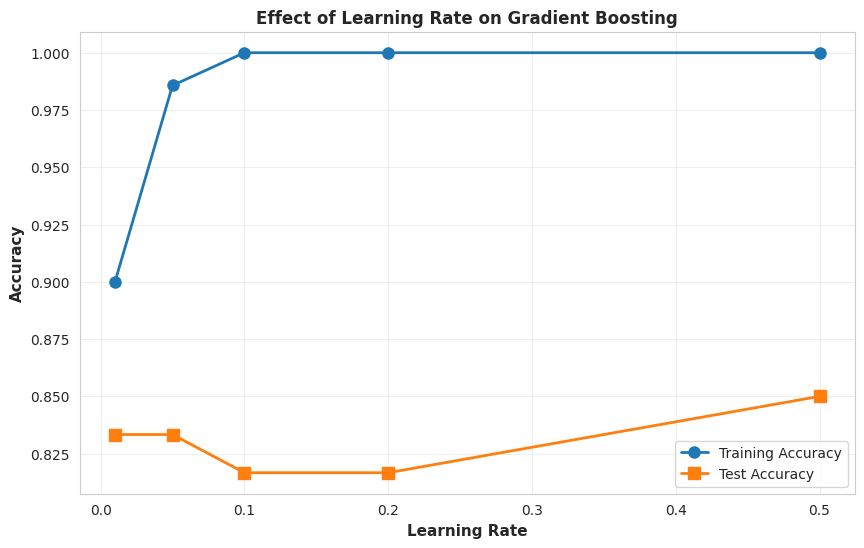

Learning rate effect on test accuracy:
  Learning rate 0.01: 0.8333
  Learning rate 0.05: 0.8333
  Learning rate 0.10: 0.8167
  Learning rate 0.20: 0.8167
  Learning rate 0.50: 0.8500


In [10]:
# Test different learning rates
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5]
lr_train_scores = []
lr_test_scores = []

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    lr_train_scores.append(gb.score(X_train, y_train))
    lr_test_scores.append(gb.score(X_test, y_test))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, lr_train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(learning_rates, lr_test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Learning Rate', fontweight='bold', fontsize=11)
plt.ylabel('Accuracy', fontweight='bold', fontsize=11)
plt.title('Effect of Learning Rate on Gradient Boosting', fontweight='bold', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print('Learning rate effect on test accuracy:')
for lr, score in zip(learning_rates, lr_test_scores):
    print(f'  Learning rate {lr:.2f}: {score:.4f}')

## 9. Overfitting in Trees: Shallow vs Deep

Limiting tree depth prevents overfitting better than post-pruning in modern frameworks.

Shallow vs Deep Tree Comparison:
                 Model  Train Accuracy  Test Accuracy  Overfitting Gap
Shallow Tree (depth=3)        0.885714       0.833333         0.052381
  Deep Tree (depth=20)        1.000000       0.850000         0.150000


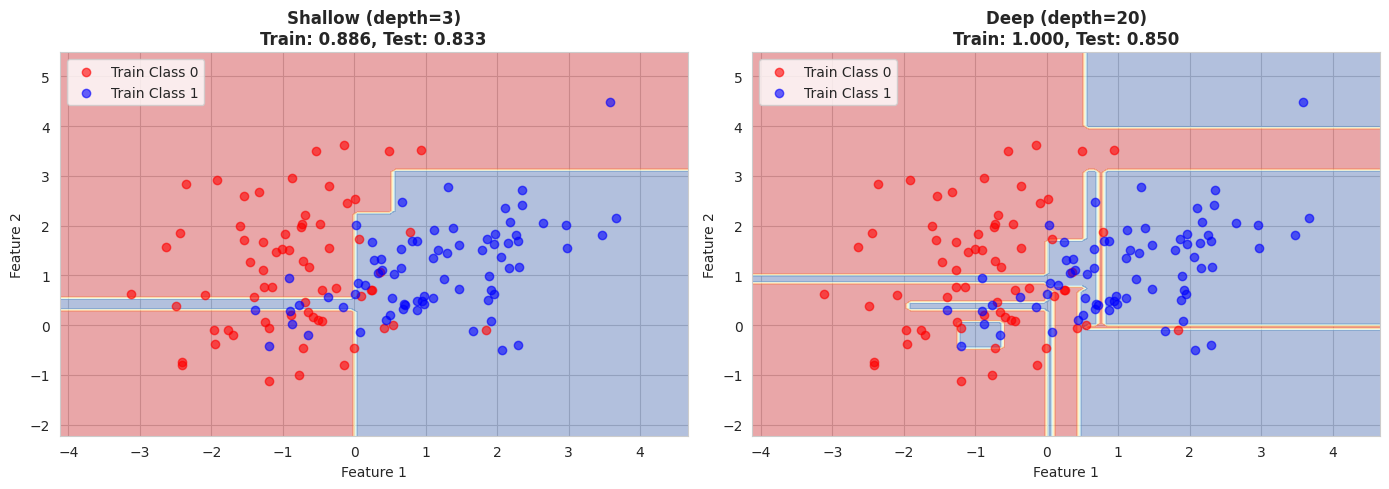

In [11]:
# Compare shallow vs deep trees
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_deep = DecisionTreeClassifier(max_depth=20, random_state=42)

dt_shallow.fit(X_train, y_train)
dt_deep.fit(X_train, y_train)

shallow_train = dt_shallow.score(X_train, y_train)
shallow_test = dt_shallow.score(X_test, y_test)
deep_train = dt_deep.score(X_train, y_train)
deep_test = dt_deep.score(X_test, y_test)

comparison = pd.DataFrame({
    'Model': ['Shallow Tree (depth=3)', 'Deep Tree (depth=20)'],
    'Train Accuracy': [shallow_train, deep_train],
    'Test Accuracy': [shallow_test, deep_test],
    'Overfitting Gap': [shallow_train - shallow_test, deep_train - deep_test]
})

print('Shallow vs Deep Tree Comparison:')
print(comparison.to_string(index=False))

# Visualize side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (dt, name) in enumerate([(dt_shallow, 'Shallow (depth=3)'), (dt_deep, 'Deep (depth=20)')]):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                          np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))
    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    axes[idx].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='red', label='Train Class 0', alpha=0.6, marker='o')
    axes[idx].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='blue', label='Train Class 1', alpha=0.6, marker='o')
    axes[idx].set_title(f'{name}\nTrain: {dt.score(X_train, y_train):.3f}, Test: {dt.score(X_test, y_test):.3f}', fontweight='bold')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 10. Key Takeaways

- Decision Trees: Simple, interpretable but prone to overfitting. Use depth limits.
- Random Forests: Reduce variance through bootstrap aggregation and random feature selection.
- Gradient Boosting: Minimize residuals sequentially; very powerful but requires tuning learning rate.
- Trade-offs: Deeper trees result in lower bias but higher variance. Shallow trees have higher bias but lower variance.
- Feature Importance: Tree-based models provide built-in feature importance from splits.

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>